In [13]:
import os
import deflacue
import glob
import music_tag
import re
from PIL import Image
import matplotlib.pyplot as plt 
import numpy as np

import chardet

from pydub import AudioSegment
from pathlib import Path

from mutagen.flac import FLAC, Picture  # Ensure proper imports for FLAC and Picture

In [74]:

example_folder = "滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]"
#audio_ext = "mp3" #assuming all files in flac
parent_dir = f"/Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/{example_folder}"


Forced audio type: flac


# 0.0 Get parameters

In [58]:
def get_encoding(cue_path):
    with open(cue_path, "rb") as f:  # Open the file in binary mode
        raw_data = f.read()
        result = chardet.detect(raw_data)
        encoding = result['encoding']
        print(f"Detected encoding: {encoding}")
    return encoding

def get_cover_path(cue_path,forced_file=None):
    if forced_file == None:
        cover_file = [x for x in os.listdir(cue_path) if x.endswith("jpg") and not x.startswith(".")][0]
        cover_path = f"{cue_path}/{cover_file}"
    else:
        cover_path = f"{cue_path}/{forforced_file}"
    aa = plt.imread(f"{cover_path}")
    plt.imshow(aa)
    plt.show
    return cover_path

def add_cover_to_flac(flac_file, cover_image_path):
    """
    Add a cover image to a FLAC file.
    """
    audio = FLAC(flac_file)
    with open(cover_image_path, 'rb') as img_file:
        image_data = img_file.read()
    
    picture = Picture()
    picture.type = 3  # Front cover
    picture.mime = "image/jpeg" if cover_image_path.endswith(".jpg") or cover_image_path.endswith(".jpeg") else "image/png"
    picture.desc = "Cover"
    picture.data = image_data

    audio.add_picture(picture)
    audio.save()

def parse_cue(cue_file,encoding = "gb18030"):
    """
    Parse the CUE file to extract track information.
    """
    tracks = []
    artist = "Unknown Artist"  # Default artist
    with open(cue_file, 'r',encoding=encoding,errors="replace") as f:
        lines = f.readlines()
        track = {}
        for line in lines:
            line = line.strip()
            if line.startswith("FILE"):
                track['file'] = line.split('"')[1]
            elif line.startswith("PERFORMER"):
                artist = line.split('"')[1]
            elif line.startswith("TRACK"):
                if track:
                    tracks.append(track)
                track = {'number': line.split()[1], 'title': '', 'start': '', 'artist': artist}
            elif line.startswith("TITLE"):
                track['title'] = line.split('"')[1]

            elif line.startswith("INDEX 01"):
                time_parts = line.split()[2].split(':')
                track['start'] = int(time_parts[0]) * 60 * 1000 + int(time_parts[1]) * 1000 + int(time_parts[2]) * 10
        if track:
            tracks.append(track)
    return tracks

def split_wav_and_convert(cue_file, output_dir,encoding = "gb18030",cover_path = None):
    """
    Split a WAV file based on a CUE file and convert the split tracks to FLAC.
    """
    tracks = parse_cue(cue_file,encoding)
    if not tracks:
        print("No tracks found in CUE file.")
        return

    cue_path = Path(cue_file)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    input_audio_path = cue_path.parent / tracks[0]['file']
    
    if not input_audio_path.exists():
        print(f"Input audio file '{input_audio_path}' not found.")
        return
    if str(input_audio_path).endswith("wav"):
        audio = AudioSegment.from_wav(input_audio_path)
    elif str(input_audio_path).endswith("ape"):
        audio = AudioSegment.from_file(input_audio_path)

    for i, track in enumerate(tracks):
        if i>0:  #The fist dict in list named "tracks" does not have a key named "start"
            start_time = track['start']
            end_time = tracks[i + 1]['start'] if i + 1 < len(tracks) else len(audio)
            track_audio = audio[start_time:end_time]
            track_title = f"{track['number']}_{track['title'].replace(' ', '_').replace('/', '-')}"
            output_flac_path = output_dir / f"{track_title}.flac"

            # Add metadata
            metadata = {
            "artist": track['artist'],
            "title": track['title']}
            
            track_audio.export(output_flac_path, format="flac", tags=metadata)
            if cover_path != None:
                add_cover_to_flac(output_flac_path, cover_path) #add cover
            print(f"Exported {output_flac_path}")

def delete_non_flac_files(cue_file_path):
    """
    Delete all files in the parent directory of the CUE file path
    that do not have a '.flac' extension.
    """
    cue_path = Path(cue_file_path)
    parent_dir = cue_path.parent

    if not parent_dir.exists():
        print(f"The directory {parent_dir} does not exist.")
        return

    for file in parent_dir.iterdir():
        if file.is_file() and file.suffix.lower() != '.flac':
            try:
                file.unlink()
                print(f"Deleted: {file}")
            except Exception as e:
                print(f"Failed to delete {file}: {e}")


# 1.0 Split files

Detected encoding: GB2312


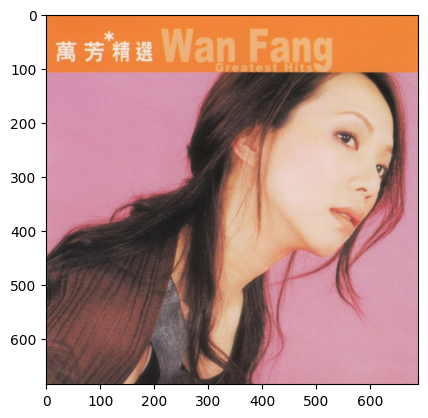

In [123]:
#Parameter paration
encoding = get_encoding(cue_path)
tracks = parse_cue(f"{cue_path}","gb18030")
cover_path = get_cover_path(f"{parent_dir}/{example_folder}")

In [127]:
#Convertion
split_wav_and_convert(cue_path, f"{parent_dir}/{example_folder}","gb18030",cover_path)

Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/01_试着了解.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/02_猜心.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/03_就值得了爱.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/04_Fly_Away.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/05_温哥华悲伤一号.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/06_孩子气.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/07_听风的歌.flac
Exported /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/08_从前.flac
Exported /Users/u0126415/Down

In [130]:
#Delete non-FLAC file
delete_non_flac_files(cue_path)

Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/封面.jpg
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/信息.txt
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/封底.jpg
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/万芳精选.wav
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/万芳精选.cue
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/滚石香港黄金十年系列《万芳精选》首版[WAV+CUE]/碟面.jpg


# 2.0 Practical execution

In [49]:
import glob
parent_dir = "/Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD"
list_ = glob.glob(f"{parent_dir}/**/*.cue", recursive=True)

def get_audio_path(cue_path,verbose=True): #audio with extension of wav or ape
    parent_directory = os.path.dirname(cue_path)

    wavs = [f for f in os.listdir(parent_directory) if f.endswith("wav") or f.endswith("ape")]

    if len(wavs)>1:
        print("More than 1 wav")

    if len(wavs) == 0:
        if verbose:
            print(f"    No file found in {parent_directory}")
        return None
    else:
        return wavs[0]

张国荣电影歌曲精选.cue
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/封底25.jpg
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/信息25.txt
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/封面25.jpg
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/张国荣电影歌曲精选.cue
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/滚石香港黄金十年系列《张国荣电影歌曲精选》首版[WAV+CUE]/张国荣电影歌曲精选.wav
任贤齐精选.cue
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《任贤齐精选》首版[WAV+CUE]/滚石香港黄金十年系列《任贤齐精选》首版[WAV+CUE]/任贤齐精选.ape
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《任贤齐精选》首版[WAV+CUE]/滚石香港黄金十年系列《任贤齐精选》首版[WAV+CUE]/任贤齐精选.cue
Deleted: /Users/u0126415/Downloads/《滚石香港黄金十年系列》35CD/滚石香港黄金十年系列《任贤齐精选》首版[WAV+CUE]/滚石香港黄金十年系列

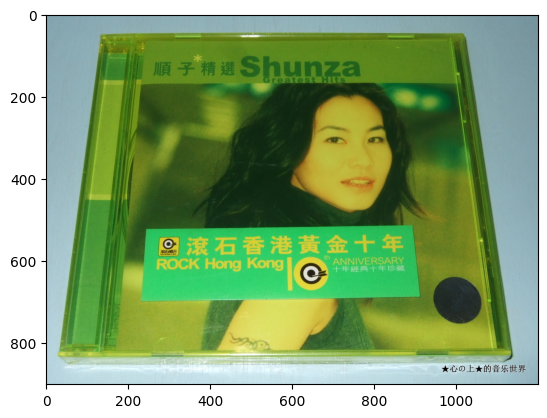

In [60]:
for i in list_:
    matched_audio = get_audio_path(i,False)
    if matched_audio != None:
        print(i.split("/")[-1])

        cue_path = i
        output_dir = os.path.dirname(cue_path)
        cover_path = get_cover_path(output_dir)
        #split_wav_and_convert(cue_path, output_dir,"gb18030",cover_path)
        #delete_non_flac_files(cue_path)

In [81]:
#reorganize folder
import shutil
parent_dir = "/Users/u0126415/Downloads/滚石香港黄金十年系列"
new_parent_dir = "/Users/u0126415/Downloads/滚石十年"
list_ = glob.glob(f"{parent_dir}/**/*.flac", recursive=True)
for i in list_:
    album_name = re.findall(r'《(.*?)》', i)[0]

    if not os.path.exists(f"{new_parent_dir}/{album_name}"):
        os.makedirs(f"{new_parent_dir}/{album_name}")

    source = i
    file_name = i.split("/")[-1]
    destination = f"{new_parent_dir}/{album_name}/{file_name}"
    #print(source)
    #print(destination)

    shutil.move(source, destination)

In [83]:
list_ = glob.glob(f"{parent_dir}/**/*.*", recursive=True)
list_

['/Users/u0126415/Downloads/滚石香港黄金十年系列/滚石香港黄金十年系列-《潘越云精选》[WAV+CUE]/滚石香港黄金十年系列-《潘越云精选》[WAV+CUE]/~$潘越云精选.txt',
 '/Users/u0126415/Downloads/滚石香港黄金十年系列/张国荣-《電影歌曲精選》滚石香港黄金十年系列[WAV+CUE]/张国荣-《電影歌曲精選》滚石香港黄金十年系列[WAV+CUE]/~$榮 - 《電影歌曲精選》（滚石香港黄金十年系列）.cue',
 '/Users/u0126415/Downloads/滚石香港黄金十年系列/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/书册/2.jpg',
 '/Users/u0126415/Downloads/滚石香港黄金十年系列/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/书册/3.jpg',
 '/Users/u0126415/Downloads/滚石香港黄金十年系列/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/滚石香港黄金十年系列《李宗盛精选》首版[WAV+CUE]/书册/1.jpg',
 '/Users/u0126415/Downloads/滚石香港黄金十年系列/滚石香港黄金十年系列《伍佰精选》首版[WAV+CUE]/滚石香港黄金十年系列《伍佰精选》首版[WAV+CUE]/~$伍佰精选.cue']